# 2.4. Ensembled techniques: Voting strategy behaviour

In [1]:
from anchoring_detection.models import Models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn import metrics
from mlxtend.plotting import plot_confusion_matrix
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, cross_val_predict

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


dataset = pd.read_pickle('/home/arturo/Documentos/Mooring_anomaly_detector/data/dataframe.pkl')

In [2]:
dataset

,Hs,Tp,Direction,m0_Surge,m0_Sway,Dragging
oc4__Hs1__Tp2__dir1__1,1.21,8.15,0,0.002438,0.001749,0
oc4__Hs1__Tp2__dir1__2,1.21,8.15,0,0.011784,0.008595,1
oc4__Hs1__Tp2__dir1__3,1.21,8.15,0,0.005411,0.005698,1
oc4__Hs1__Tp2__dir1__4,1.21,8.15,0,0.002285,0.003390,1
oc4__Hs1__Tp2__dir2__1,1.21,8.15,60,0.002250,0.001852,0
...,...,...,...,...,...,...
oc4__Hs4__Tp5__dir3__2,8.10,18.69,90,0.012230,0.018121,1
oc4__Hs4__Tp5__dir4__1,8.10,18.69,120,0.005428,0.010878,0
oc4__Hs4__Tp5__dir4__2,8.10,18.69,120,0.012206,0.016706,1
oc4__Hs4__Tp5__dir5__1,8.10,18.69,180,0.011085,0.002734,0


## Prepare data

The user can apply transformations described in [*models>transform_dataset*](/home/arturo/Documentos/Mooring_anomaly_detector/anchoring_detection/models.py)

In [3]:
drag_models = Models()

In [4]:
X_train_min_max, X_test_min_max, Y_train, Y_test = drag_models.transform_dataset(dataset)

The training set contains the Surge and Sway spectral moments in a 2D array

In [5]:
X_train_min_max

array([[0.00698358, 0.08528962],
       [0.01479205, 0.00191339],
       [0.00537408, 0.10163946],
       [0.07170368, 0.64738316],
       [0.13279204, 0.22928384],
       [0.97379166, 0.44280775],
       [0.02292324, 0.00992097],
       [0.02498603, 0.26900404],
       [0.03661853, 0.00448592],
       [0.46194614, 0.04524715],
       [0.05851568, 0.04525578],
       [0.80010464, 0.28760974],
       [0.00234019, 0.02315467],
       [0.59827887, 0.44251679],
       [0.54892333, 0.06513841],
       [0.59337273, 0.42081638],
       [0.60988548, 0.40667915],
       [0.57558169, 0.42438641],
       [0.67948669, 0.43384154],
       [0.        , 0.02048375],
       [0.61626008, 0.27170729],
       [0.66738549, 0.46234012],
       [0.58478244, 0.42107766],
       [0.02389493, 0.39263281],
       [0.12769059, 0.15162937],
       [0.07700594, 0.10509197],
       [0.61160497, 0.42066791],
       [0.65091093, 0.41372954],
       [0.00869242, 0.01133714],
       [0.01081056, 0.18879129],
       [0.

The approach of training is with supervised learning. It is store the data according two class, **Healthy (0)** and **Draging (1)**

In [6]:
Y_train

oc4__Hs1__Tp5__dir3__1    0
oc4__Hs1__Tp3__dir1__1    0
oc4__Hs1__Tp3__dir1__4    1
oc4__Hs4__Tp5__dir3__1    0
oc4__Hs2__Tp5__dir2__1    0
                         ..
oc4__Hs3__Tp5__dir5__1    0
oc4__Hs1__Tp3__dir1__3    1
oc4__Hs3__Tp4__dir4__1    0
oc4__Hs2__Tp3__dir1__4    1
oc4__Hs3__Tp5__dir3__1    0
Name: Dragging, Length: 96, dtype: int64

## First training

Check how model perform without hyperparams

In [7]:
model1 = LogisticRegression()
model2 = DecisionTreeClassifier()
model3 = SVC(probability=True)

voting_model = VotingClassifier(estimators=[
    ('lr', model1), ('dt', model2), ('svc', model3)], voting='soft')

In [8]:
voting_model.fit(X_train_min_max,Y_train)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('dt', DecisionTreeClassifier()),
                             ('svc', SVC(probability=True))],
                 voting='soft')

Due to the orthogonal nature of the decision boundaries in DecisionTree, it very easily falls into overfitting.

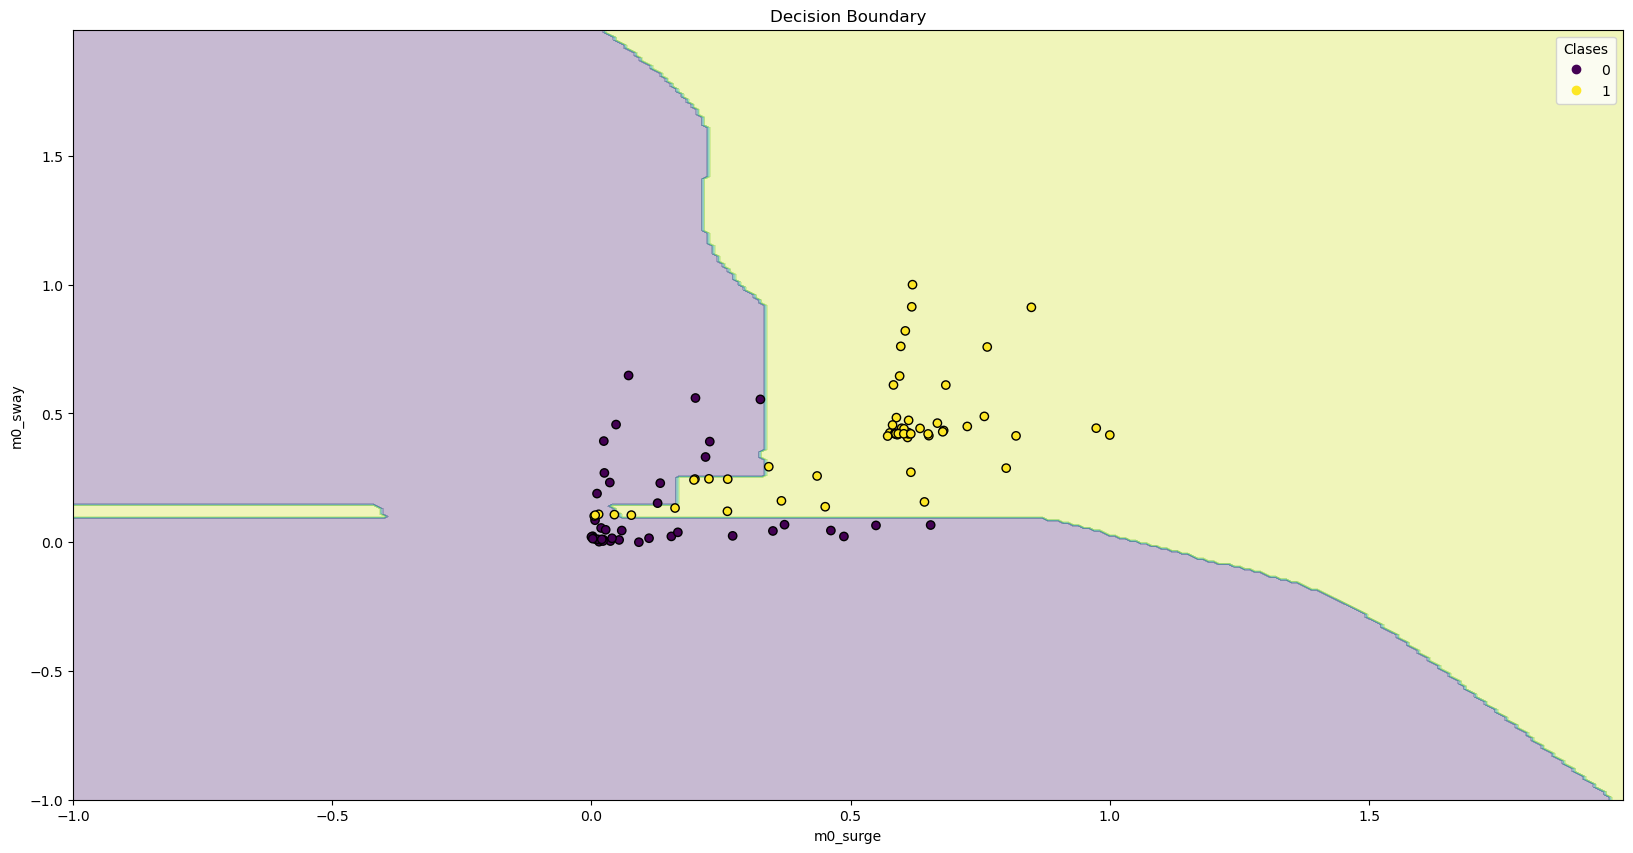

In [9]:
drag_models.decision_boundary(model=voting_model,X=X_train_min_max,y=Y_train)

Can be made cross validation and see the metrics

In [9]:
train_scores = cross_val_score(voting_model,X_train_min_max, Y_train, cv=5)

In [10]:
train_scores

array([1.        , 0.94736842, 0.94736842, 0.89473684, 0.78947368])

In [11]:
train_pred = cross_val_predict(voting_model,X_train_min_max, Y_train, cv=5)

In [12]:
cm, df_metrics =drag_models.return_metrics(Y=Y_train, Y_pred=train_pred)

In [13]:
df_metrics

,accuracy,precision,recall,f1
0,0.895833,0.943396,0.877193,0.909091


Text(0.5, 1.0, 'Voting')

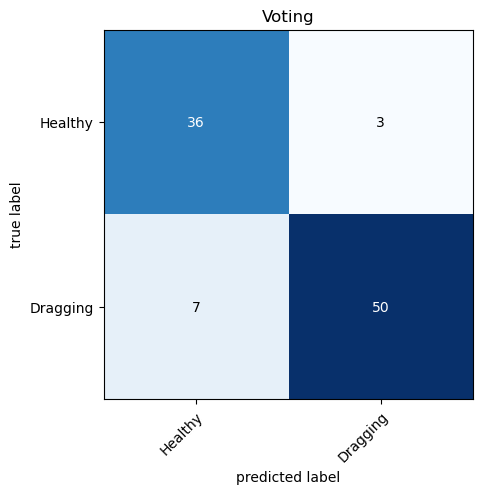

In [14]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Voting')

## Hyperparams selection

Applied hyperparams list selected in the previous model notebooks

## New training

Retraining model with hyperparameters

In [15]:
model1 = LogisticRegression(C=10,penalty='l1',solver='liblinear')
model2 = DecisionTreeClassifier(max_depth=3,max_leaf_nodes=4,min_samples_leaf=4,min_samples_split=5,criterion='gini')
model3 = SVC(probability=True,C=1,kernel='linear')

voting_model = VotingClassifier(estimators=[
    ('lr', model1), ('dt', model2), ('svc', model3)], voting='soft')

In [16]:
voting_model.fit(X_train_min_max,Y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=10, penalty='l1',
                                                 solver='liblinear')),
                             ('dt',
                              DecisionTreeClassifier(max_depth=3,
                                                     max_leaf_nodes=4,
                                                     min_samples_leaf=4,
                                                     min_samples_split=5)),
                             ('svc',
                              SVC(C=1, kernel='linear', probability=True))],
                 voting='soft')

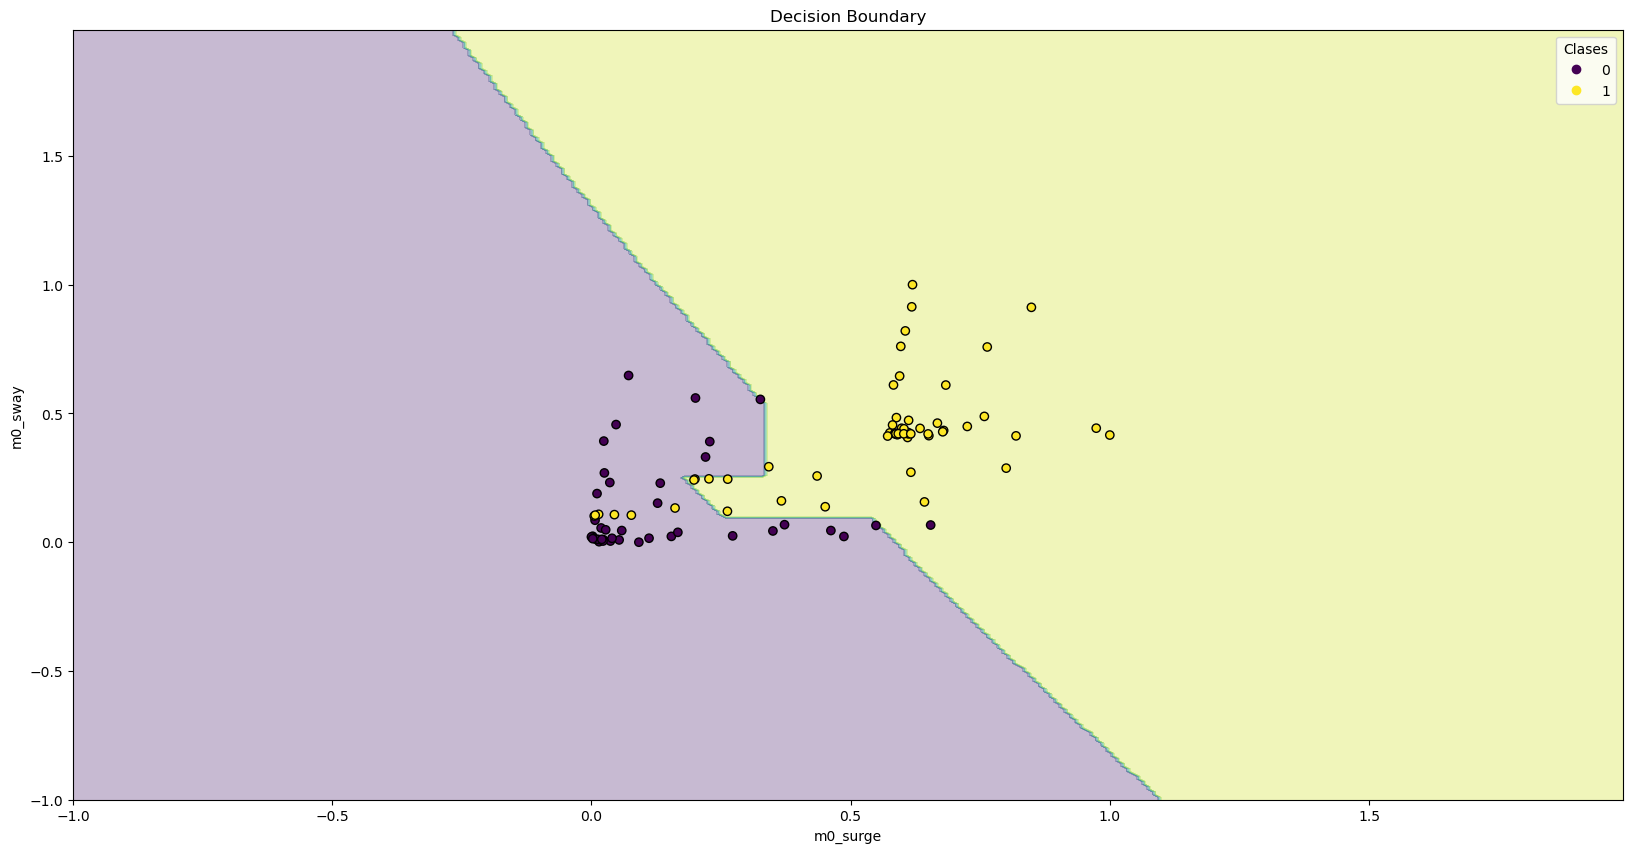

In [17]:
drag_models.decision_boundary(voting_model,X=X_train_min_max,y=Y_train)

In [19]:
train_scores = cross_val_score(voting_model,X_train_min_max, Y_train, cv=5)

In [20]:
train_scores

array([0.9       , 0.94736842, 0.84210526, 0.89473684, 0.68421053])

In [21]:
train_pred = cross_val_predict(voting_model,X_train_min_max, Y_train, cv=5)

In [22]:
cm, df_metrics =drag_models.return_metrics(Y=Y_train, Y_pred=train_pred)

- Apply all hyperparams list produce an important decreace of the recall. It perform worse than models working individually

In [23]:
df_metrics

,accuracy,precision,recall,f1
0,0.854167,0.957447,0.789474,0.865385


Text(0.5, 1.0, 'Decision tree')

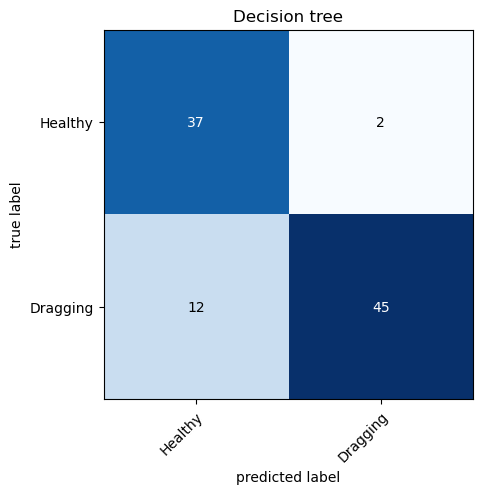

In [24]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Decision tree')

## Predictions

In [25]:
Y_pred_test = voting_model.predict(X_test_min_max)

ATTENTION: Note that you are now working with model test arrays.

In [26]:
cm, df_metrics =drag_models.return_metrics(Y=Y_test, Y_pred=Y_pred_test)

In [27]:
df_metrics

,accuracy,precision,recall,f1
0,0.958333,1.0,0.923077,0.96


Text(0.5, 1.0, 'Decision tree')

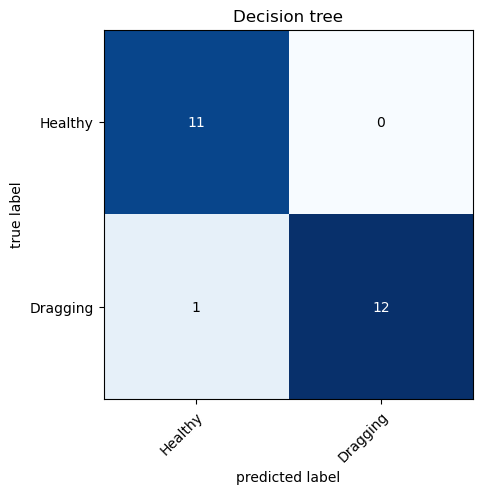

In [28]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Decision tree')

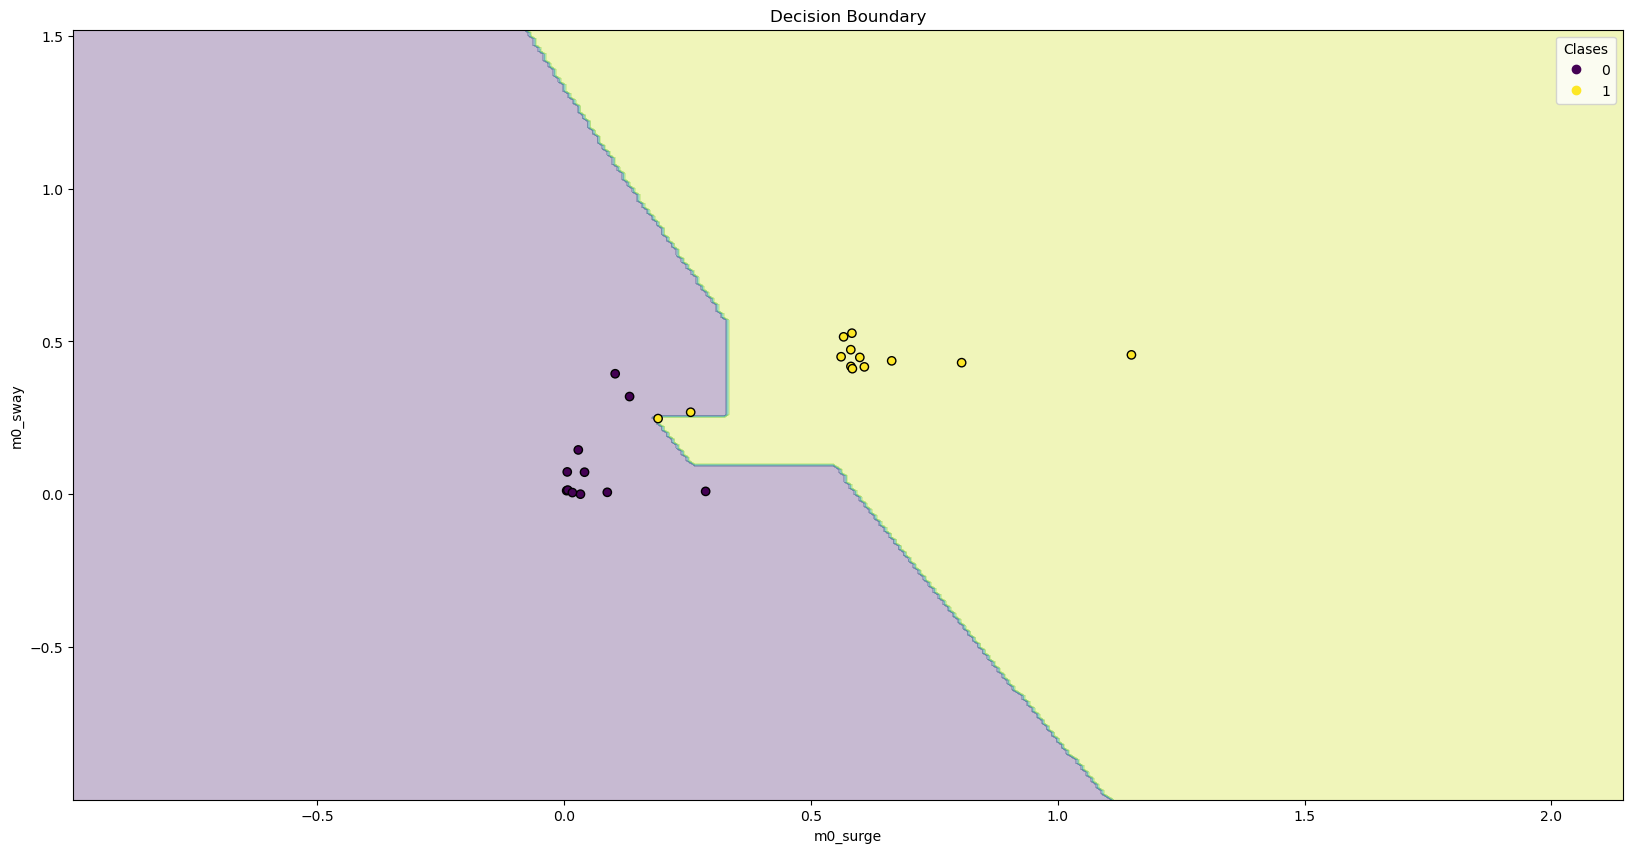

In [29]:
drag_models.decision_boundary(voting_model,X=X_test_min_max,y=Y_test)

CONCLUSION: The influence of LogisticRegression and SVM is minimal. Perhaps the second model generates better results by applying non-linear kernels, however, there are better ensemble techniques with which we can boost the performance of DecisionTrees.